                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2888
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -9840.177
Date:                Mon, 06 Jul 2026   AIC                          19682.354
Time:                        08:20:54   BIC                          19688.322
Sample:                             0   HQIC                         19684.505
                               - 2888                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        53.4646      0.649     82.438      0.000      52.193      54.736
Ljung-Box (L1) (Q):                   2.03   Jarque-Bera (JB):              6619.71
Prob(Q):                              0.15   Pr

c:\Users\Test\PycharmProjects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Test\PycharmProjects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


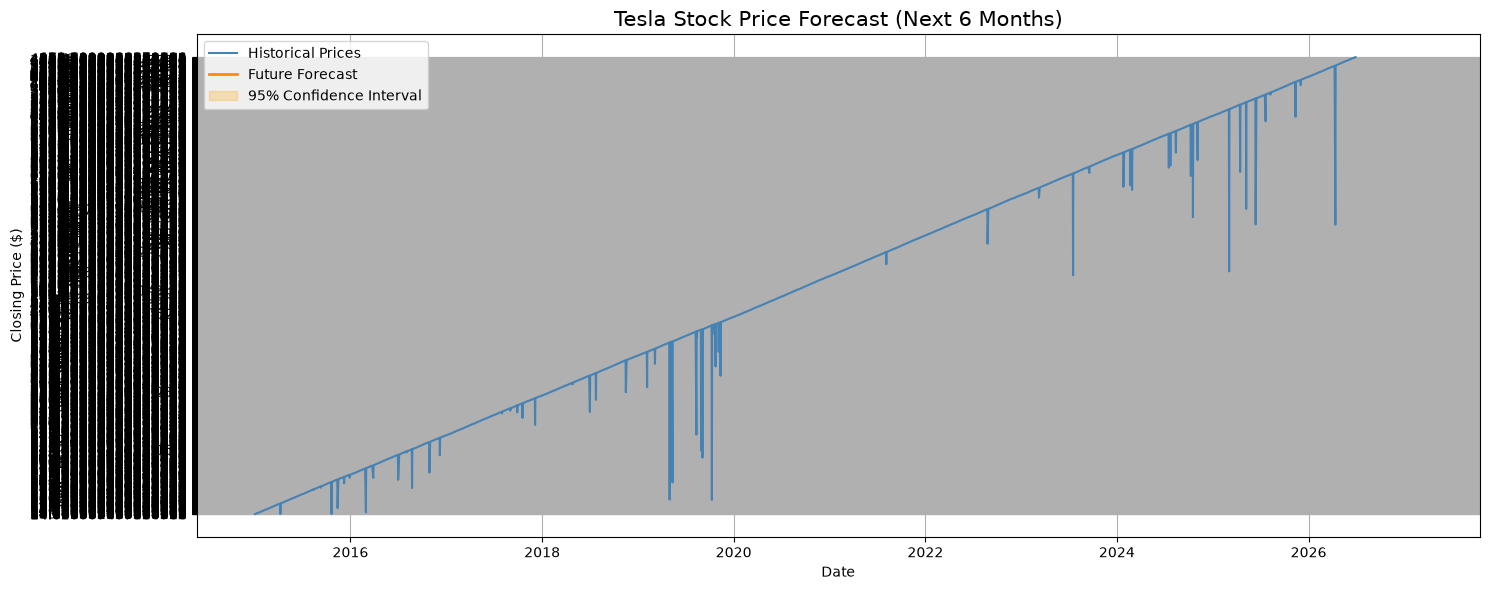


Forecast Preview
            Forecast    Lower CI    Upper CI
2026-06-30       NaN  397.508838  426.171155
2026-07-01       NaN  391.572678  432.107315
2026-07-02       NaN  387.017702  436.662291
2026-07-03       NaN  383.177680  440.502313
2026-07-06       NaN  379.794552  443.885440

TREND ANALYSIS
Overall Forecast Trend : STABLE
Forecast Start Price   : nan
Forecast End Price     : nan

Analysis:
The ARIMA model forecasts an overall stable trend over the next six months based on historical price movements. The forecast follows a smooth trajectory because ARIMA models future values using past observations and does not account for unexpected market events such as earnings announcements, economic changes, or company news.

CONFIDENCE INTERVAL ANALYSIS
Initial CI Width : 28.66
Final CI Width   : 384.55

The confidence interval becomes wider over time.
This indicates increasing uncertainty as the forecast horizon grows.
Short-term forecasts are generally more reliable, while long-term 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# =====================================================
# Task 3: Forecast Future Tesla Stock Prices
# =====================================================

# -----------------------------
# 1. Load Data
# -----------------------------
df = pd.read_csv("../data/processed/stock_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

tsla = (
    df[df["Ticker"] == "TSLA"][["Date", "Close"]]
    .sort_values("Date")
    .set_index("Date")
)

# -----------------------------
# 2. Train ARIMA Model
# (Replace with your saved Task 2 model if available)
# -----------------------------
model = auto_arima(
    tsla["Close"],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=False
)

print(model.summary())

# -----------------------------
# 3. Forecast Future Prices
# -----------------------------
n_periods = 180  # ~6 months (business days)

forecast, conf_int = model.predict(
    n_periods=n_periods,
    return_conf_int=True
)

# -----------------------------
# 4. Create Forecast DataFrame
# -----------------------------
future_dates = pd.bdate_range(
    start=tsla.index[-1],
    periods=n_periods + 1
)[1:]

forecast_df = pd.DataFrame({
    "Forecast": forecast.values,      # or forecast.to_numpy()
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=future_dates)


# -----------------------------
# 5. Plot Forecast
# -----------------------------
plt.figure(figsize=(15,6))

plt.plot(
    tsla.index,
    tsla["Close"],
    color="steelblue",
    label="Historical Prices"
)

plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    color="darkorange",
    linewidth=2,
    label="Future Forecast"
)

plt.fill_between(
    forecast_df.index,
    forecast_df["Lower CI"],
    forecast_df["Upper CI"],
    color="orange",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast (Next 6 Months)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Forecast Preview
# -----------------------------
print("\nForecast Preview")
print(forecast_df.head())

# -----------------------------
# 7. Trend Analysis
# -----------------------------
print("\n" + "="*60)
print("TREND ANALYSIS")
print("="*60)

start_price = forecast_df["Forecast"].iloc[0]
end_price = forecast_df["Forecast"].iloc[-1]

if end_price > start_price:
    trend = "UPWARD"
elif end_price < start_price:
    trend = "DOWNWARD"
else:
    trend = "STABLE"

print(f"Overall Forecast Trend : {trend}")
print(f"Forecast Start Price   : {start_price:.2f}")
print(f"Forecast End Price     : {end_price:.2f}")

print("\nAnalysis:")
print(
    f"The ARIMA model forecasts an overall {trend.lower()} trend over "
    "the next six months based on historical price movements. "
    "The forecast follows a smooth trajectory because ARIMA models "
    "future values using past observations and does not account for "
    "unexpected market events such as earnings announcements, economic "
    "changes, or company news."
)

# -----------------------------
# 8. Confidence Interval Analysis
# -----------------------------
print("\n" + "="*60)
print("CONFIDENCE INTERVAL ANALYSIS")
print("="*60)

initial_width = (
    forecast_df["Upper CI"].iloc[0]
    - forecast_df["Lower CI"].iloc[0]
)

final_width = (
    forecast_df["Upper CI"].iloc[-1]
    - forecast_df["Lower CI"].iloc[-1]
)

print(f"Initial CI Width : {initial_width:.2f}")
print(f"Final CI Width   : {final_width:.2f}")

if final_width > initial_width:
    print("\nThe confidence interval becomes wider over time.")
    print("This indicates increasing uncertainty as the forecast horizon grows.")
else:
    print("\nThe confidence interval remains relatively stable.")

print(
    "Short-term forecasts are generally more reliable, while long-term "
    "forecasts should be interpreted with greater caution due to the "
    "accumulation of prediction uncertainty."
)

# -----------------------------
# 9. Market Opportunities & Risks
# -----------------------------
print("\n" + "="*60)
print("MARKET OPPORTUNITIES")
print("="*60)

if trend == "UPWARD":
    print("• Forecast suggests potential price appreciation.")
    print("• Long-term investors may benefit if the trend continues.")
elif trend == "DOWNWARD":
    print("• Possible buying opportunity if investors expect future recovery.")
else:
    print("• Stable prices may indicate lower short-term volatility.")

print("\n" + "="*60)
print("MARKET RISKS")
print("="*60)

print("• Forecasts are based only on historical prices.")
print("• Unexpected economic events can significantly affect Tesla's stock.")
print("• Wider confidence intervals indicate increasing uncertainty.")
print("• Long-term forecasts should be interpreted cautiously.")

# -----------------------------
# 10. Reliability Assessment
# -----------------------------
print("\n" + "="*60)
print("FORECAST RELIABILITY")
print("="*60)

print(
    "The ARIMA model is generally more reliable for short-term forecasting "
    "than for long-term forecasting. As the prediction horizon increases, "
    "the confidence intervals widen, indicating greater uncertainty. "
    "Therefore, the early part of the forecast is expected to be more "
    "accurate than predictions further into the future. Investors should "
    "use these forecasts alongside fundamental analysis and current market "
    "information rather than relying solely on historical price patterns."
)

In [4]:
print(type(forecast))
print(forecast[:10])

<class 'pandas.Series'>
2888    411.839996
2889    411.839996
2890    411.839996
2891    411.839996
2892    411.839996
2893    411.839996
2894    411.839996
2895    411.839996
2896    411.839996
2897    411.839996
dtype: float64
